In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv("../data/raw/train.csv")

train_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [3]:
train_df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
164724,164724,255893,255894,If everyone who lives in Texas ran for Governo...,What are some good medical universities that o...,0
7746,7746,15121,15122,Why is communism considered evil by some people?,Why do people think Communism is evil?,0
121389,121389,196712,196713,"Unable to Process Your Request, Please try aga...",Islamic state vs al qaeda who would win?,0
332446,332446,459437,459438,Why does my light turn on quickly upon switchi...,Why is the drift velocity of electrons so low?...,0
347602,347602,453099,451204,"Without saying the name of it, what would be y...",How do you evaluate this indefinite integral [...,0


In [4]:
test_df = pd.read_csv("../data/raw/test.csv")

test_df.head()

,test_id,question1,question2
0,0,How does the Surface Pro himself 4 compare wit...,Why did Microsoft choose core m3 and not core ...
1,1,Should I have a hair transplant at age 24? How...,How much cost does hair transplant require?
2,2,What but is the best way to send money from Ch...,What you send money to China?
3,3,Which food not emulsifiers?,What foods fibre?
4,4,"How ""aberystwyth"" start reading?",How their can I start reading?


In [5]:
test_df.sample(5)

,test_id,question1,question2
1870053,1870053,What good Data possible tools are out there?,Where can I large datasets open to the public?
568962,568962,What is the most awkward moment as an stay?,What's your most those awkward moment?
1579727,1579727,Where are good music classes to learn vocals v...,Initial packages indigestion Google?
1563429,1563429,Dating Etiquette: How do you treat a woman ''l...,How should a woman treat a man?
1547188,1547188,What for amcat?,How sexual I prepare for amcat svar test?


In [6]:
print(train_df.shape)
print(test_df.shape)

(404290, 6)
(2345796, 3)


In [7]:
train_df.isna().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [8]:
train_df[train_df['question1'].isna()]

,id,qid1,qid2,question1,question2,is_duplicate
363362,363362,493340,493341,NaN,My Chinese name is Haichao Yu. What English na...,0


In [9]:
train_df[train_df['question2'].isna()]

,id,qid1,qid2,question1,question2,is_duplicate
105780,105780,174363,174364,How can I develop android app?,NaN,0
201841,201841,303951,174364,How can I create an Android app?,NaN,0


### id to delete from train_df - 105780, 201841, 363362

In [10]:
test_df.isna().sum()

test_id      0
question1    2
question2    4
dtype: int64

In [11]:
test_df[test_df['question1'].isna()]

,test_id,question1,question2
1046690,1046690,NaN,How I what can learn android app development?
1461432,1461432,NaN,How distinct can learn android app development?


In [12]:
test_df[test_df['question2'].isna()]

,test_id,question1,question2
379205,379205,How I can learn android app development?,NaN
817520,817520,How real can learn android app development?,NaN
943911,943911,How app development?,NaN
1270024,1270024,How I can learn app development?,NaN


### id to delete from test_df - 379205, 817520, 943911, 1046690, 1270024, 1461432

In [14]:
dup = (train_df["is_duplicate"] == 1).sum()
all_pairs = train_df["is_duplicate"].notna().sum()

dup_ratio = dup / all_pairs * 100
print(f"Dup ratio: {dup_ratio:.4f}%")

Dup ratio: 36.9198%


In [21]:
pd.set_option('display.max_colwidth', None)

In [22]:
train_df[train_df["is_duplicate"] == 0].sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
1312,1312,2616,2617,What is the life of mechanical engineers graduated from top colleges who didn't select in campus placemats?,Why do many engineering graduates from top notch colleges such as IITs/NITs pursue an MBA immediately after graduation?,0
266924,266924,384174,280842,How do I choose an engineering college and branch after 12 th?,How should I choose which branch in engineering is the best for me?,0
132965,132965,212792,212793,How should you care for 6 week old kittens?,How do you care for a 7 week old kitten?,0
74868,74868,82074,128230,How can you monetize websites like Reddit?,How can I monetize my website?,0
194873,194873,295182,91539,What kind of economy does the United States have compared to the one in France?,What kind of economy does the United States have compared to the economies of other countries?,0


In [23]:
train_df[train_df["is_duplicate"] == 1].sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
269798,269798,387556,387557,What is the typical weather during December in London and how does it compare to the summer months?,"How can the weather of London in December be described, and how does it compare to that of the same city in summer?",1
177408,177408,234780,95626,Which are the best gear bicycles in India under 10000?,"Which is the best bicycle to buy, under ₹10,000 in India?",1
250084,250084,12241,33093,What would be your New Year resolutions for 2017?,What are your New Year resolutions for the upcoming year 2017?,1
94637,94637,157993,54820,How do I remove my questions?,How do I delete my former questions?,1
328505,328505,455051,455052,What are good jobs for people with autism?,What are good jobs for autistic people?,1


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [42]:
%config InlineBackend.figure_format = 'retina'  
  
sns.set_style('darkgrid')  
sns.set_palette('muted')  
plt.rcParams['figure.figsize'] = (12, 8)

In [63]:
len_in_symbols = pd.concat([
    train_df["question1"].str.len(),
    train_df["question2"].str.len()
]).dropna().tolist()

percentile_99_symbols = np.percentile(len_in_symbols, 99)
percentile_99_symbols

np.float64(157.0)

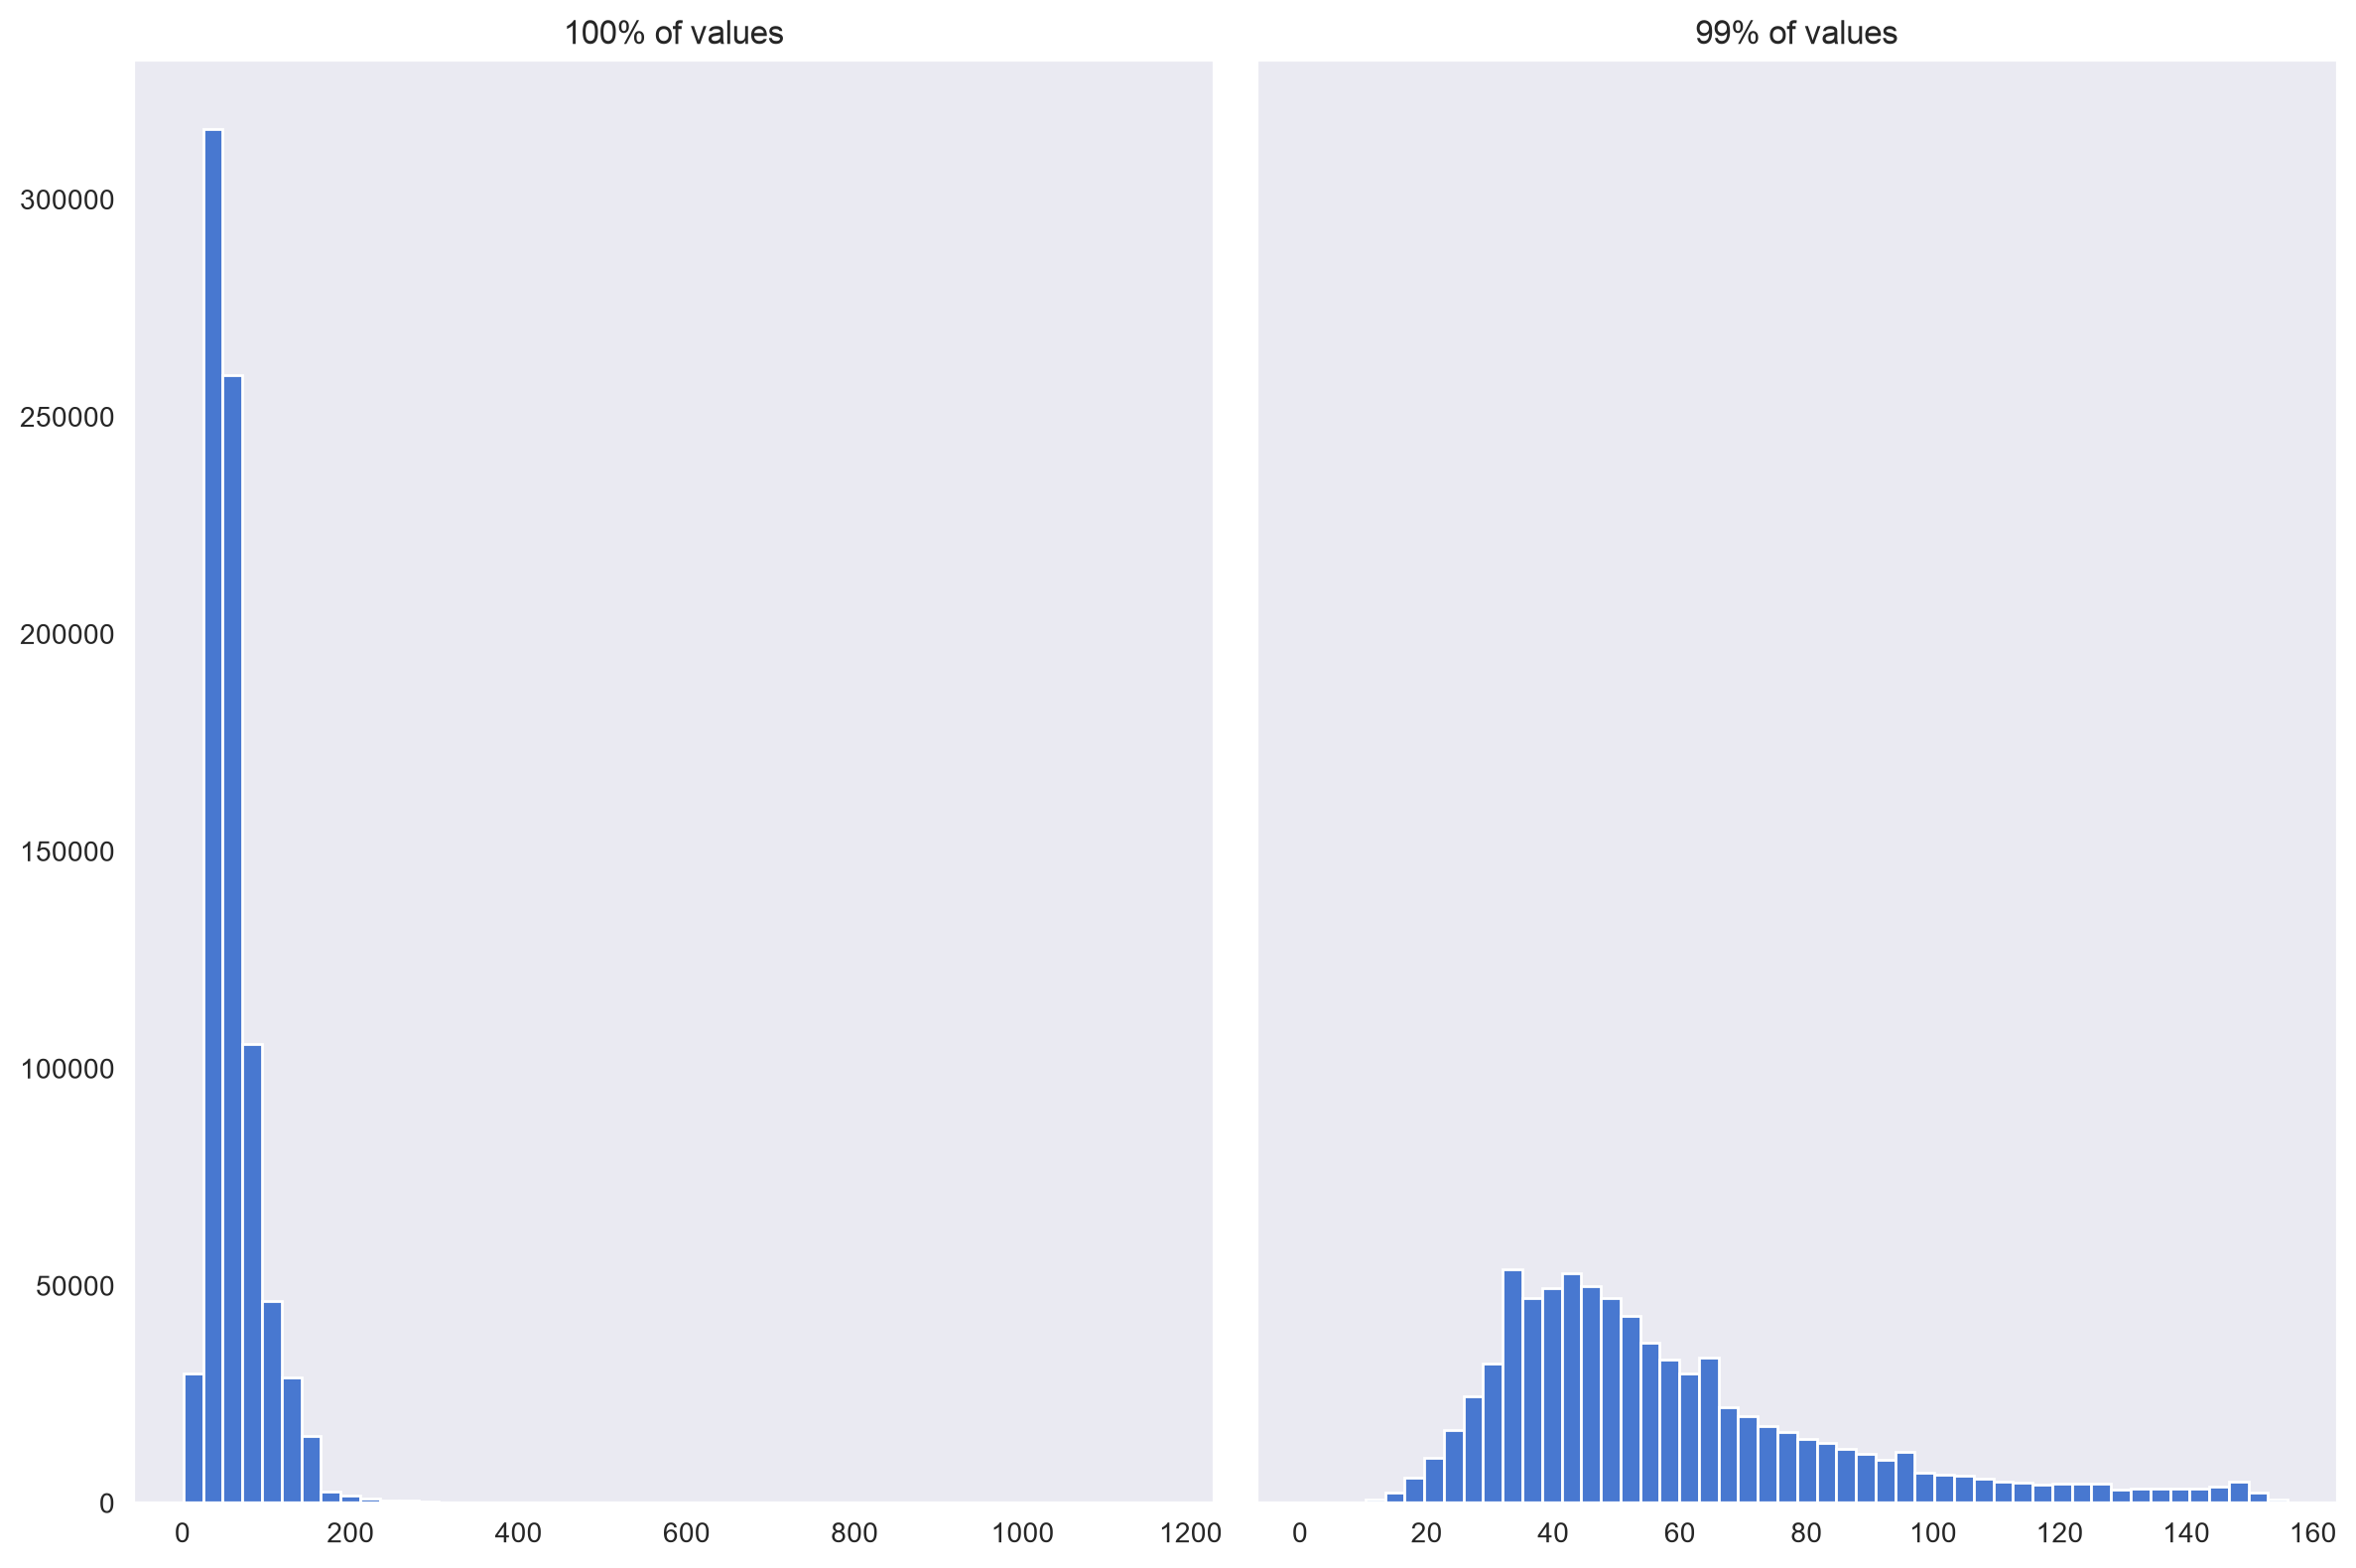

In [64]:
fig, axes = plt.subplots(1, 2, sharey=True)

axes[0].set_title("100% of values")
axes[0].hist(len_in_symbols, bins=50)
axes[0].grid()

axes[1].set_title("99% of values")
axes[1].hist([x for x in len_in_symbols if x < percentile_99_symbols], bins=50)
axes[1].grid()

plt.tight_layout()
plt.show()

In [65]:
len_in_words = pd.concat([
    train_df["question1"].str.split().str.len(),
    train_df["question2"].str.split().str.len()
]).dropna().tolist()

percentile_99_words = np.percentile(len_in_words, 99)
percentile_99_words

np.float64(31.0)

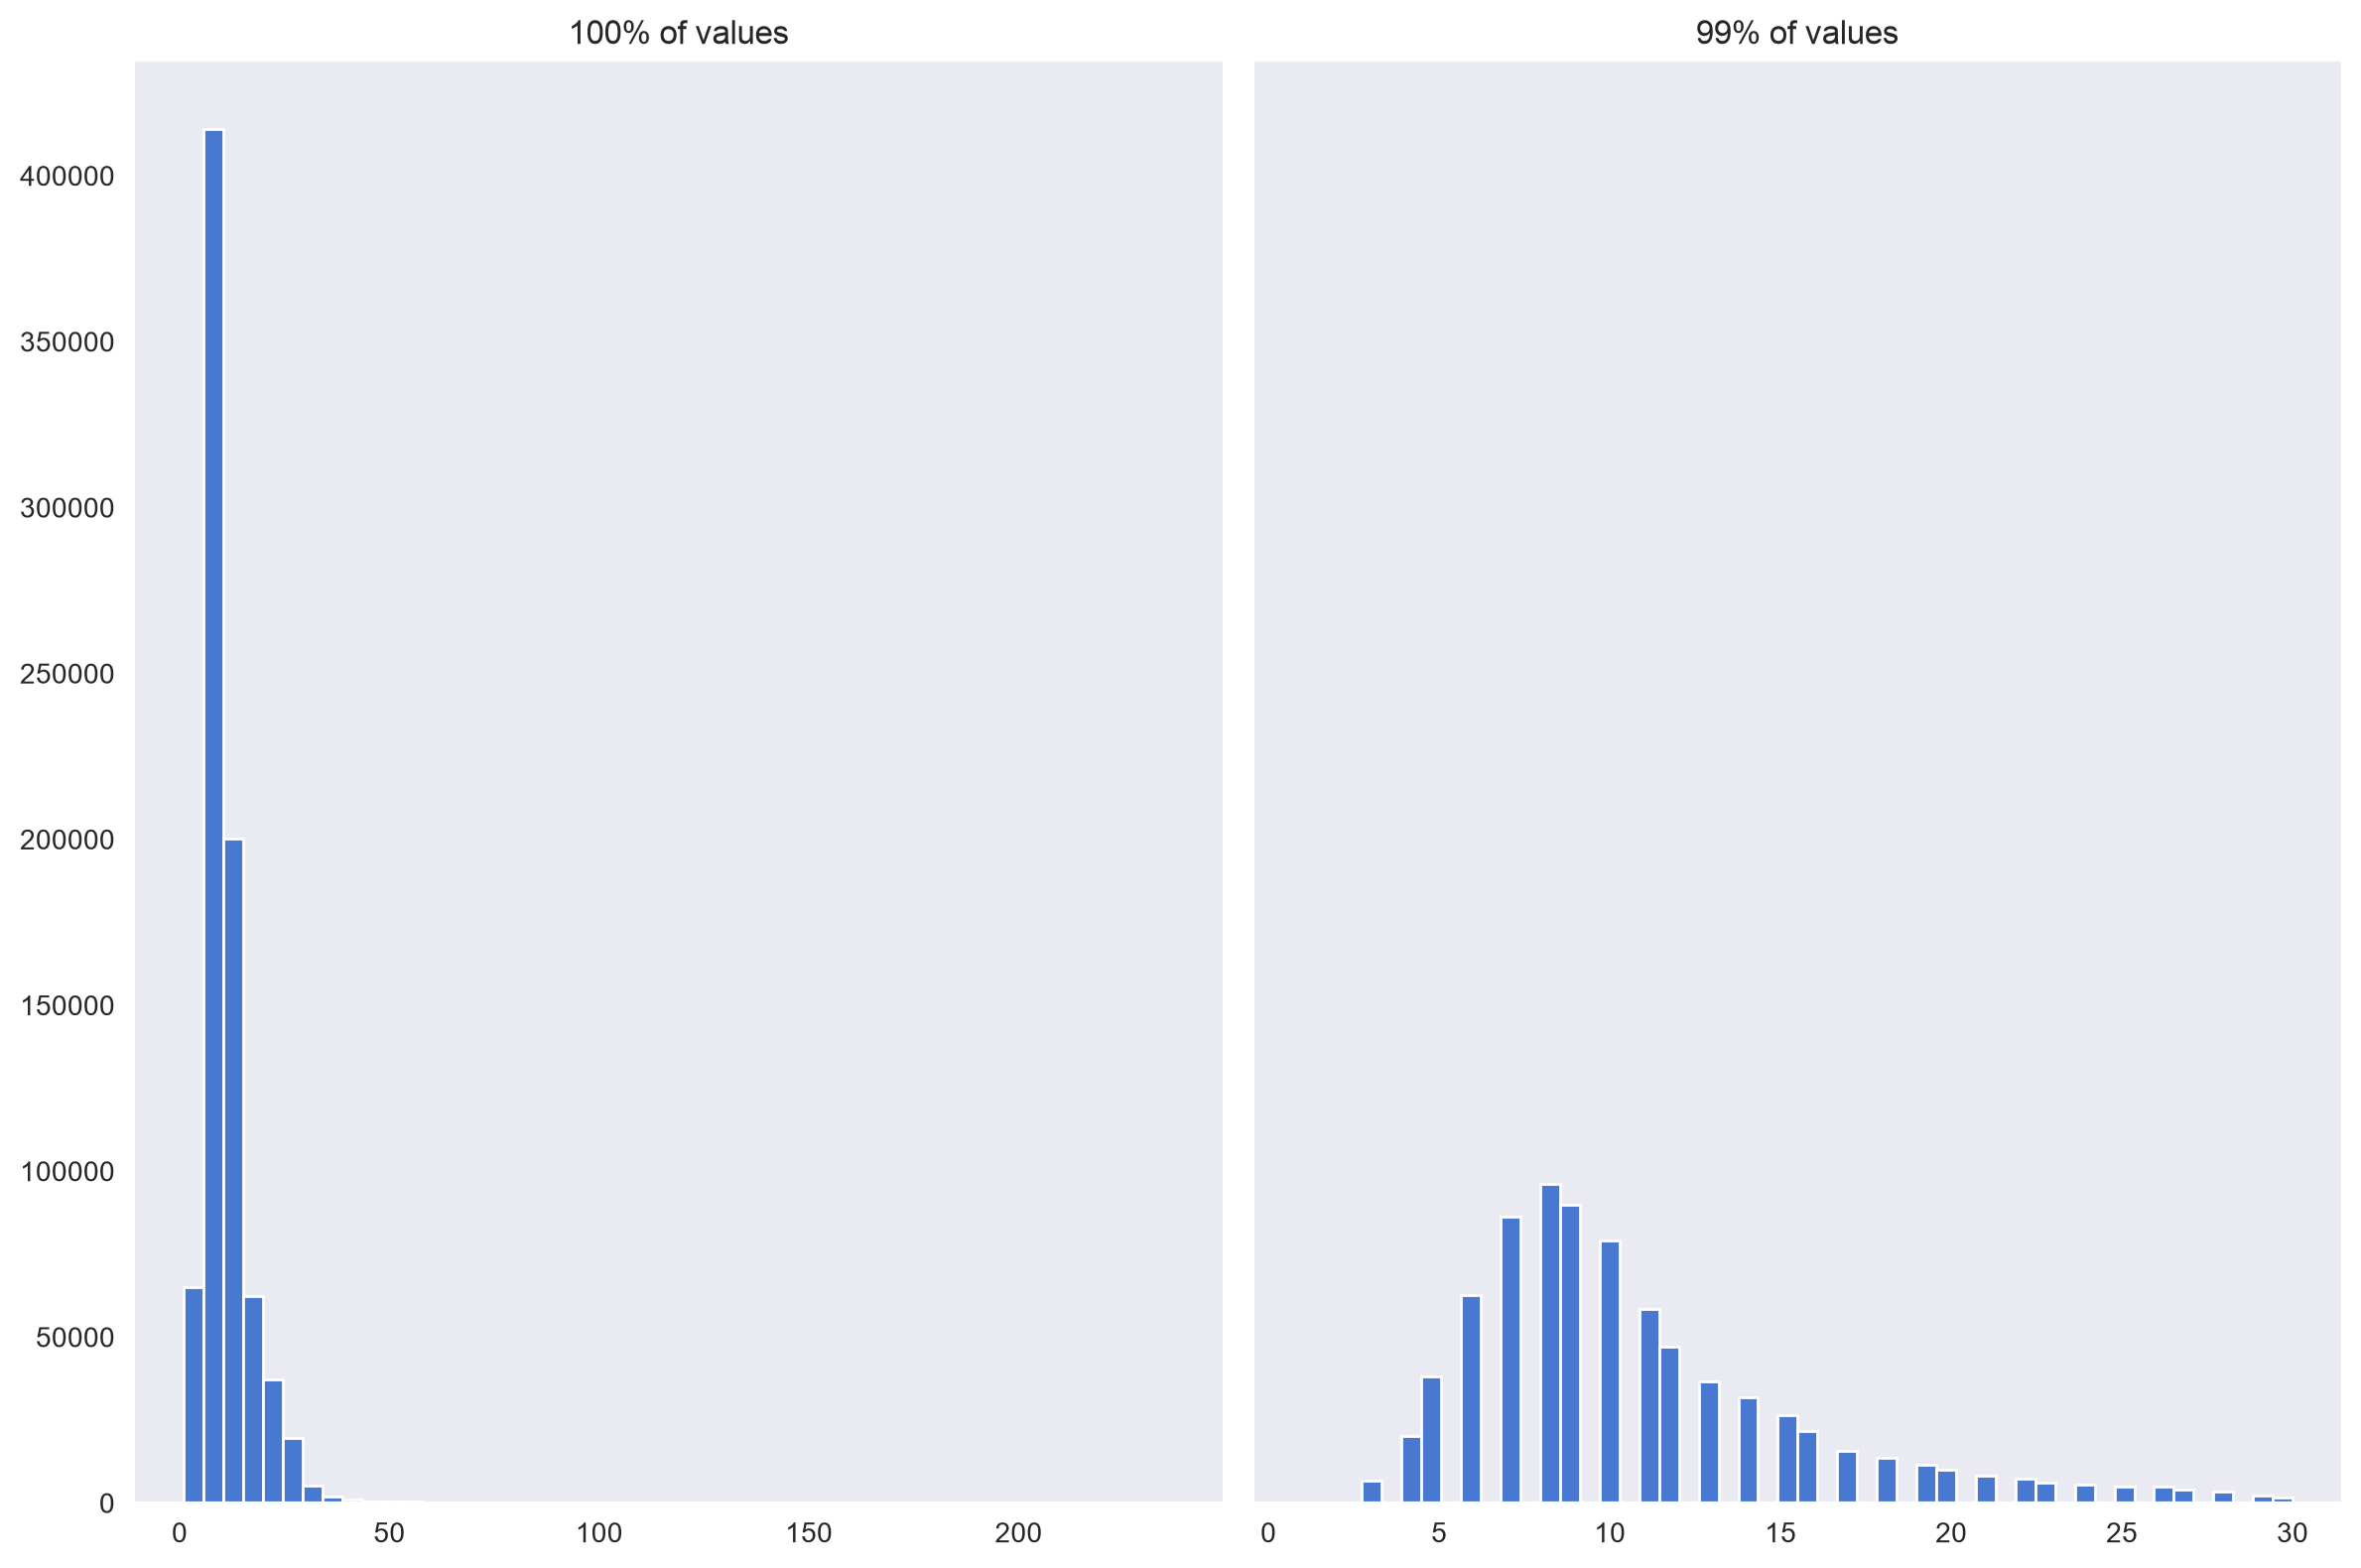

In [66]:
fig, axes = plt.subplots(1, 2, sharey=True)

axes[0].set_title("100% of values")
axes[0].hist(len_in_words, bins=50)
axes[0].grid()

axes[1].set_title("99% of values")
axes[1].hist([x for x in len_in_words if x < percentile_99_words], bins=50)
axes[1].grid()

plt.tight_layout()
plt.show()

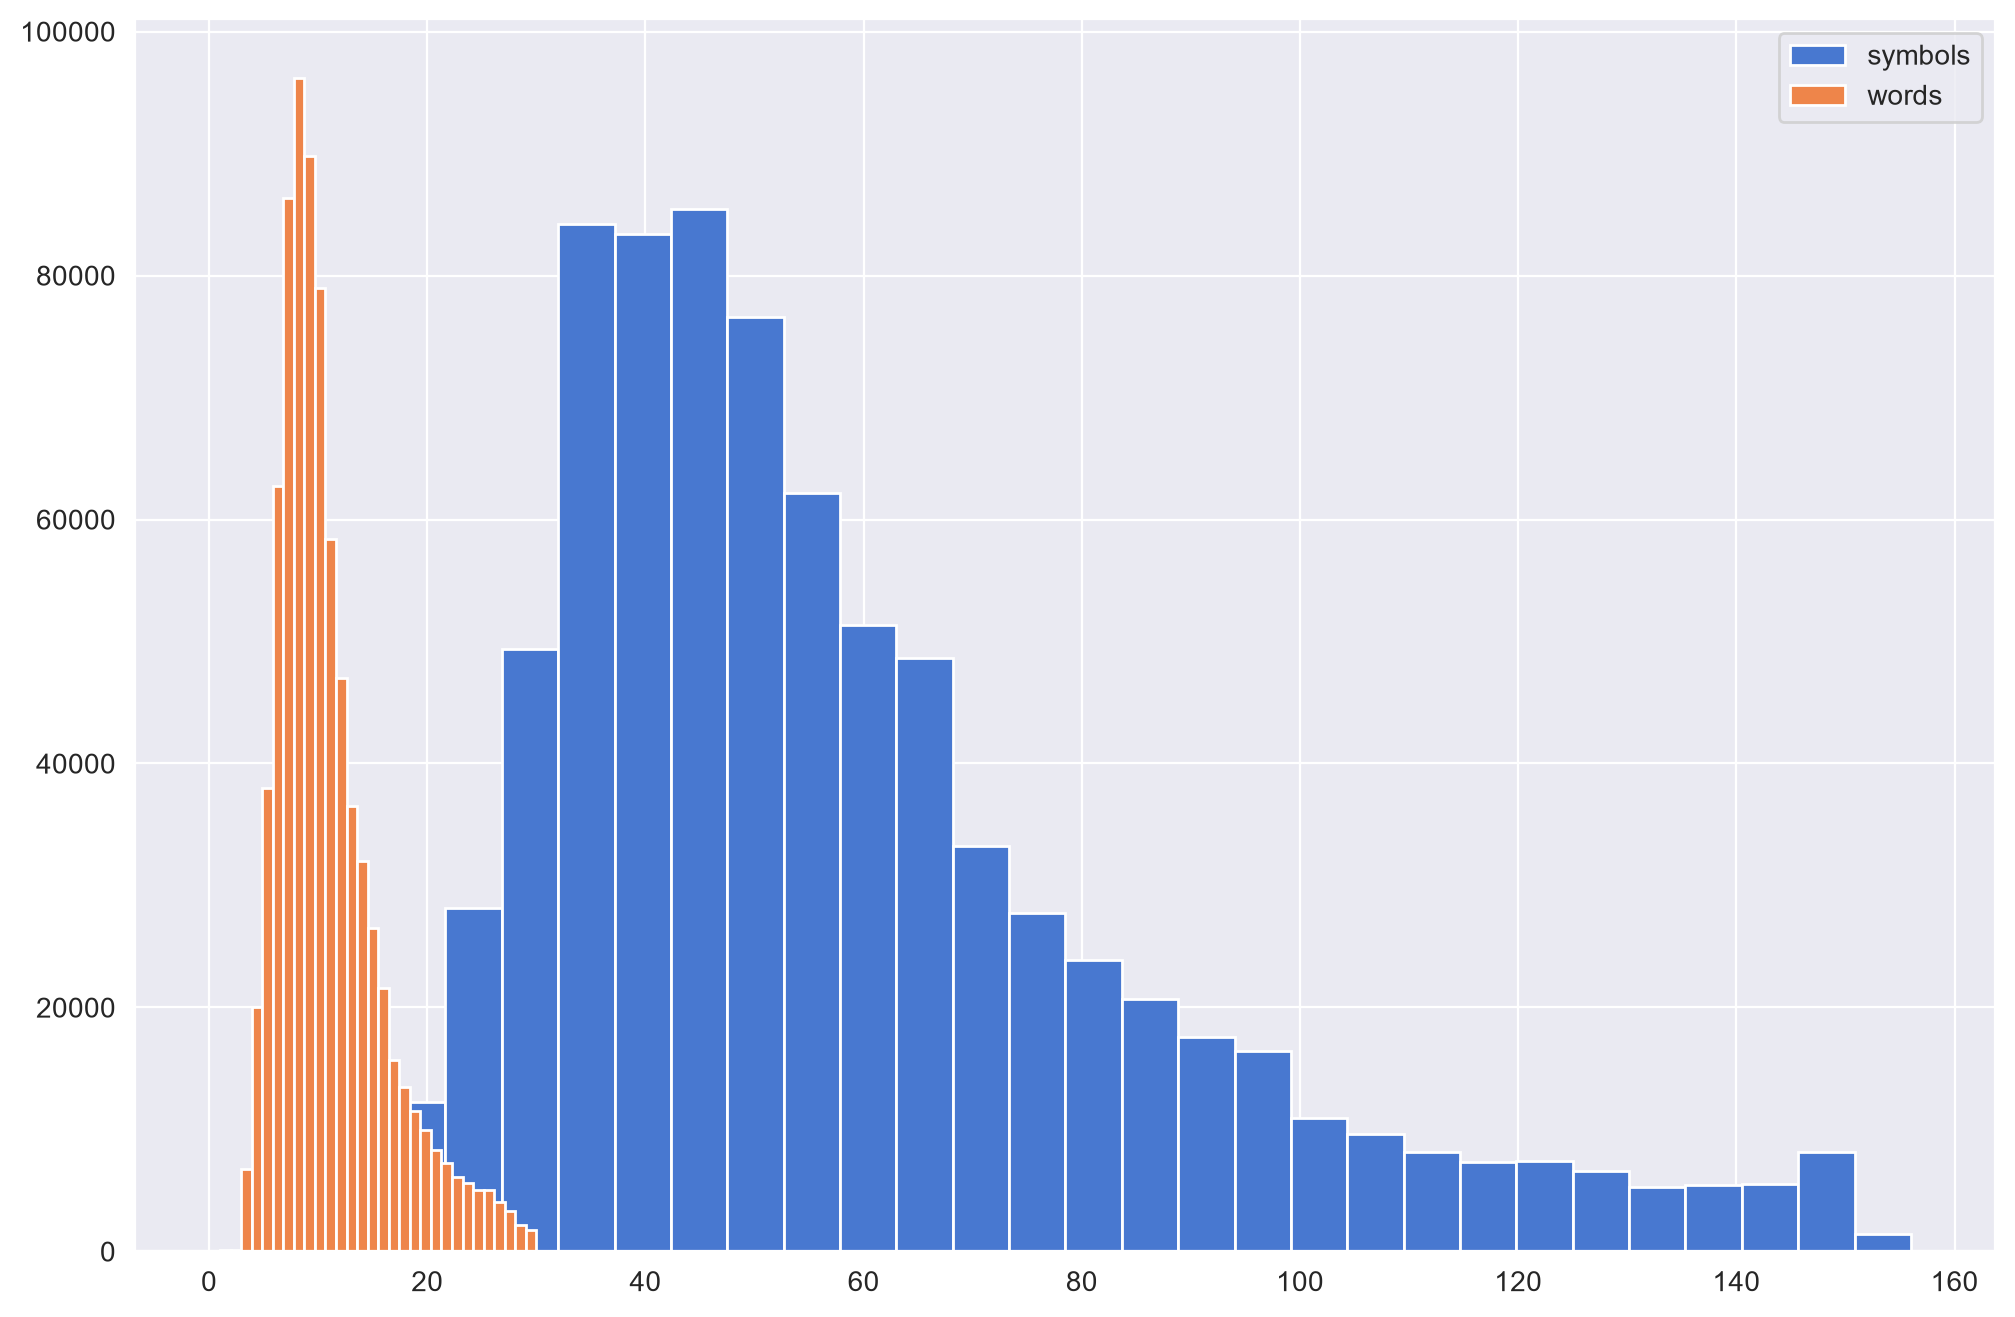

In [69]:
plt.hist([x for x in len_in_symbols if x < percentile_99_symbols], bins=30, label="symbols")
plt.hist([x for x in len_in_words if x < percentile_99_words], bins=30, label="words")

plt.legend()
plt.show()

In [71]:
all_questions = pd.concat([
    train_df["question1"],
    train_df["question2"]
]).dropna().astype(str)

questions_lower = all_questions.str.lower()

def is_in_lines(elem):
    elem = str(elem).lower()
    return questions_lower.str.contains(elem, regex=False).any()

In [73]:
elems_to_check = [
    "<", "</", "'", ">", "!", "@", "#", "$", "%", "^", "&", "*", "(", ")", "_", "-", "+", "="
]

for elem in elems_to_check:
    print(f"{elem}: {is_in_lines(elem)}")

<: True
</: True
': True
>: True
!: True
@: True
#: True
$: True
%: True
^: True
&: True
*: True
(: True
): True
_: True
-: True
+: True
=: True
